In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
df = pd.read_csv("../data/customers.csv")
df.head()

,annual_income_k,spending_score
0,34.0,82.9
1,28.9,84.5
2,35.2,88.7
3,42.2,88.4
4,28.1,69.0


In [3]:
df.shape

(600, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   annual_income_k  600 non-null    float64
 1   spending_score   600 non-null    float64
dtypes: float64(2)
memory usage: 9.5 KB


In [5]:
df.isnull().sum()

annual_income_k    0
spending_score     0
dtype: int64

In [6]:
df.describe()

,annual_income_k,spending_score
count,600.000000,600.000000
mean,68.380833,63.887167
std,28.833117,28.681534
min,15.000000,3.400000
25%,34.075000,30.575000
50%,80.500000,77.100000
75%,90.700000,86.125000
max,120.800000,100.000000


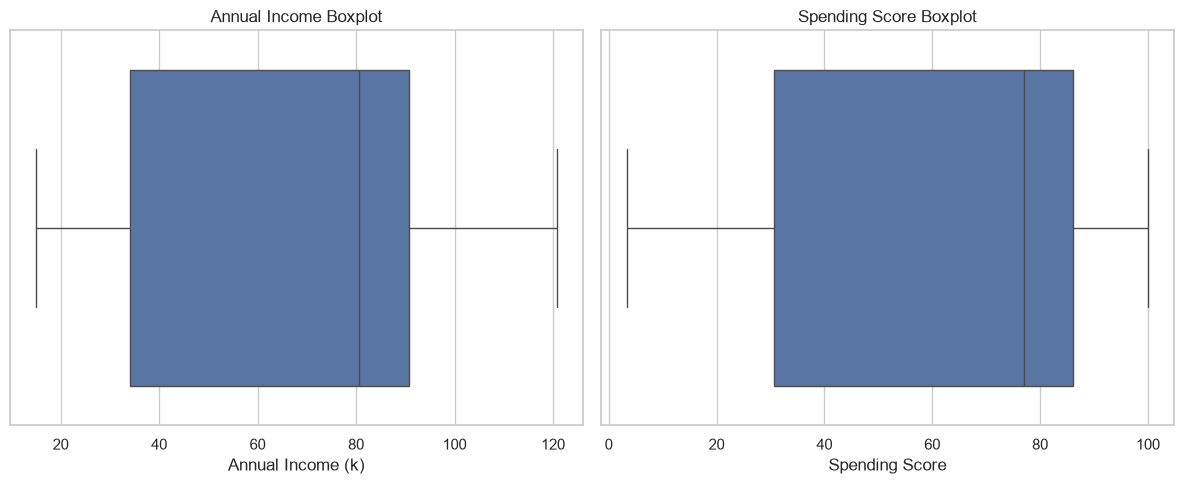

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["annual_income_k"])
plt.title("Annual Income Boxplot")
plt.xlabel("Annual Income (k)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["spending_score"])
plt.title("Spending Score Boxplot")
plt.xlabel("Spending Score")

plt.tight_layout()
plt.show()

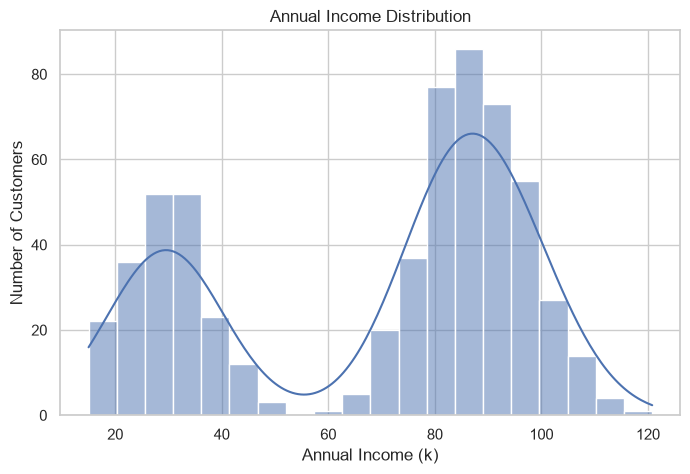

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["annual_income_k"],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k)")
plt.ylabel("Number of Customers")

plt.show()

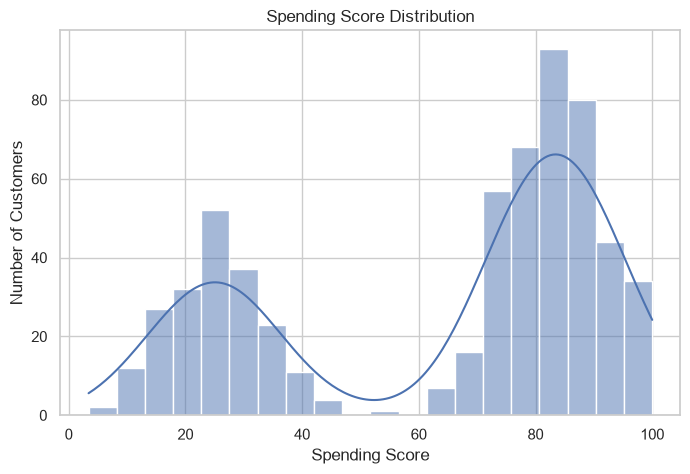

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["spending_score"],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

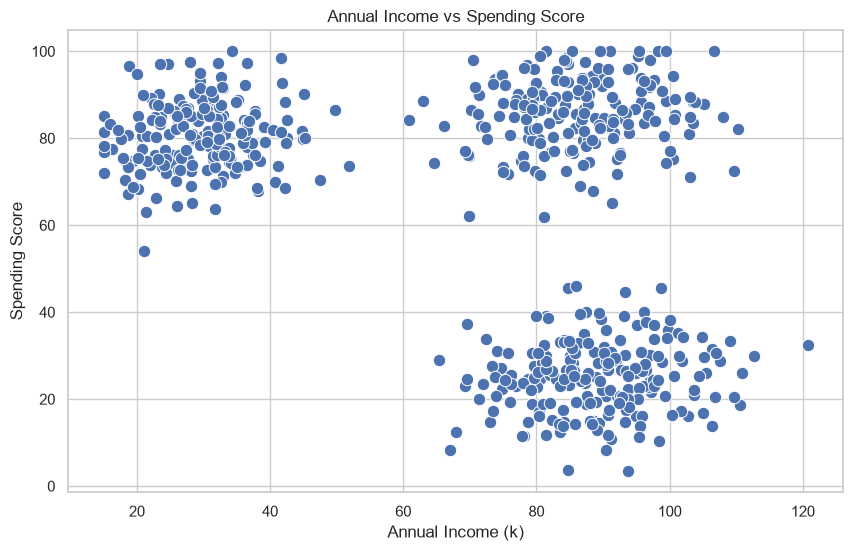

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")

plt.show()

In [17]:
df.corr()

,annual_income_k,spending_score
annual_income_k,1.000000,-0.418723
spending_score,-0.418723,1.000000


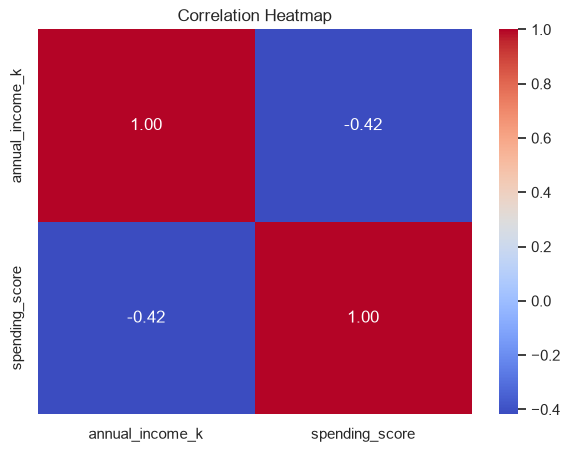

In [18]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

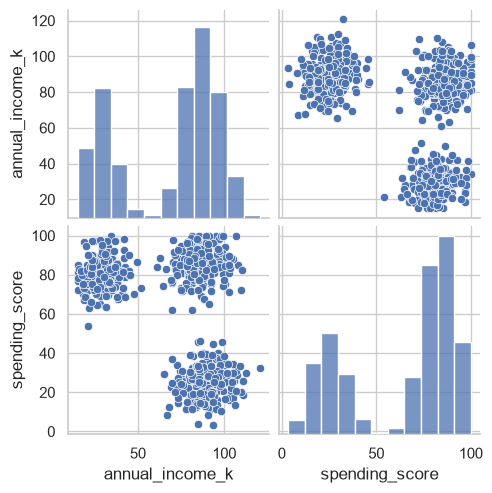

In [19]:
sns.pairplot(df)

plt.show()

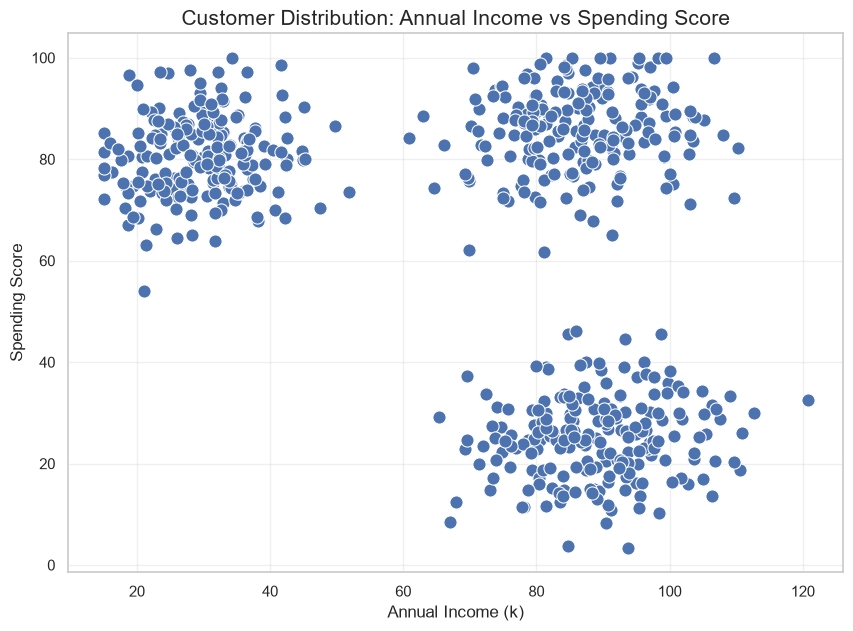

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    s=90
)

plt.title(
    "Customer Distribution: Annual Income vs Spending Score",
    fontsize=15
)

plt.xlabel(
    "Annual Income (k)",
    fontsize=12
)

plt.ylabel(
    "Spending Score",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.show()  

In [3]:
features = [
    "annual_income_k",
    "spending_score"
]

X = df[features]

X.head()

,annual_income_k,spending_score
0,34.0,82.9
1,28.9,84.5
2,35.2,88.7
3,42.2,88.4
4,28.1,69.0


In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()

In [6]:
X_scaled = scaler.fit_transform(X)

In [7]:
X_scaled[:5]

array([[-1.19340271,  0.66344769],
       [-1.37043024,  0.71927926],
       [-1.15174918,  0.86583712],
       [-0.90877022,  0.85536871],
       [-1.39819926,  0.17841094]])

In [8]:
X_scaled.mean(axis=0)

array([ 2.36847579e-16, -1.89478063e-16])

In [9]:
from sklearn.cluster import KMeans

In [10]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

In [11]:
for k, value in zip(K_range, inertia):
    print(f"K = {k}, Inertia = {value:.2f}")

K = 2, Inertia = 493.66
K = 3, Inertia = 104.78
K = 4, Inertia = 89.20
K = 5, Inertia = 74.63
K = 6, Inertia = 64.91
K = 7, Inertia = 58.01
K = 8, Inertia = 51.24
K = 9, Inertia = 44.80
K = 10, Inertia = 40.18


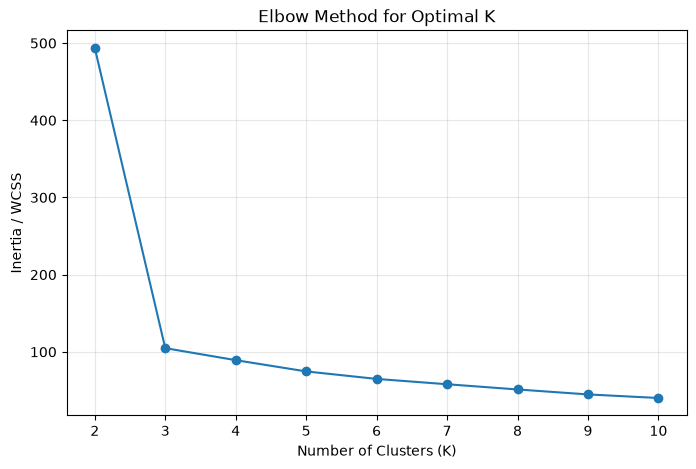

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")

plt.xticks(K_range)
plt.grid(alpha=0.3)

plt.show()

In [13]:
from sklearn.metrics import silhouette_score

In [14]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores.append(score)

In [15]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.5805
K = 3, Silhouette Score = 0.7357
K = 4, Silhouette Score = 0.6025
K = 5, Silhouette Score = 0.4722
K = 6, Silhouette Score = 0.3374
K = 7, Silhouette Score = 0.3421
K = 8, Silhouette Score = 0.3399
K = 9, Silhouette Score = 0.3569
K = 10, Silhouette Score = 0.3548


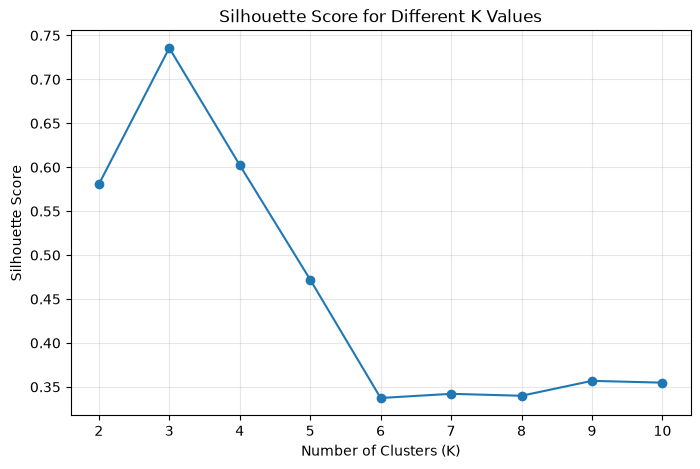

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(K_range)
plt.grid(alpha=0.3)

plt.show()

In [17]:
optimal_k = 3

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 3


In [18]:
print(X.shape)
print(X_scaled.shape)
print(optimal_k)

(600, 2)
(600, 2)
3


In [19]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

In [20]:
cluster_labels = kmeans.fit_predict(X_scaled)

In [21]:
cluster_labels[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [22]:
df["cluster"] = cluster_labels

In [23]:
df.head()

,annual_income_k,spending_score,cluster
0,34.0,82.9,1
1,28.9,84.5,1
2,35.2,88.7,1
3,42.2,88.4,1
4,28.1,69.0,1


In [24]:
df["cluster"].value_counts().sort_index()

cluster
0    200
1    200
2    200
Name: count, dtype: int64

In [25]:
cluster_summary = df.groupby("cluster")[
    ["annual_income_k", "spending_score"]
].mean()

cluster_summary

,annual_income_k,spending_score
cluster,,
0,86.2840,85.9550
1,29.7140,80.6345
2,89.1445,25.0720


In [26]:
cluster_summary = df.groupby("cluster").agg(
    customer_count=("cluster", "count"),
    average_income=("annual_income_k", "mean"),
    average_spending=("spending_score", "mean")
)

cluster_summary

,customer_count,average_income,average_spending
cluster,,,
0,200,86.2840,85.9550
1,200,29.7140,80.6345
2,200,89.1445,25.0720


In [27]:
cluster_summary = cluster_summary.round(2)

cluster_summary

,customer_count,average_income,average_spending
cluster,,,
0,200,86.28,85.96
1,200,29.71,80.63
2,200,89.14,25.07


In [28]:
cluster_ranges = df.groupby("cluster").agg(
    customer_count=("cluster", "count"),
    avg_income=("annual_income_k", "mean"),
    min_income=("annual_income_k", "min"),
    max_income=("annual_income_k", "max"),
    avg_spending=("spending_score", "mean"),
    min_spending=("spending_score", "min"),
    max_spending=("spending_score", "max")
)

cluster_ranges.round(2)

,customer_count,avg_income,min_income,max_income,avg_spending,min_spending,max_spending
cluster,,,,,,,
0,200,86.28,60.8,110.3,85.96,61.8,100.0
1,200,29.71,15.0,51.8,80.63,54.1,100.0
2,200,89.14,65.3,120.8,25.07,3.4,46.1


In [29]:
kmeans.cluster_centers_

array([[ 0.62144182,  0.77005109],
       [-1.34217525,  0.58439368],
       [ 0.72073343, -1.35444477]])

In [30]:
centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=[
        "annual_income_k",
        "spending_score"
    ]
)

centroids_df

,annual_income_k,spending_score
0,86.2840,85.9550
1,29.7140,80.6345
2,89.1445,25.0720


In [31]:
final_cluster_summary = pd.DataFrame({
    "customer_count": df["cluster"].value_counts().sort_index(),
    "average_income": df.groupby("cluster")["annual_income_k"].mean(),
    "average_spending": df.groupby("cluster")["spending_score"].mean()
})

final_cluster_summary = final_cluster_summary.round(2)

final_cluster_summary

,customer_count,average_income,average_spending
cluster,,,
0,200,86.28,85.96
1,200,29.71,80.63
2,200,89.14,25.07


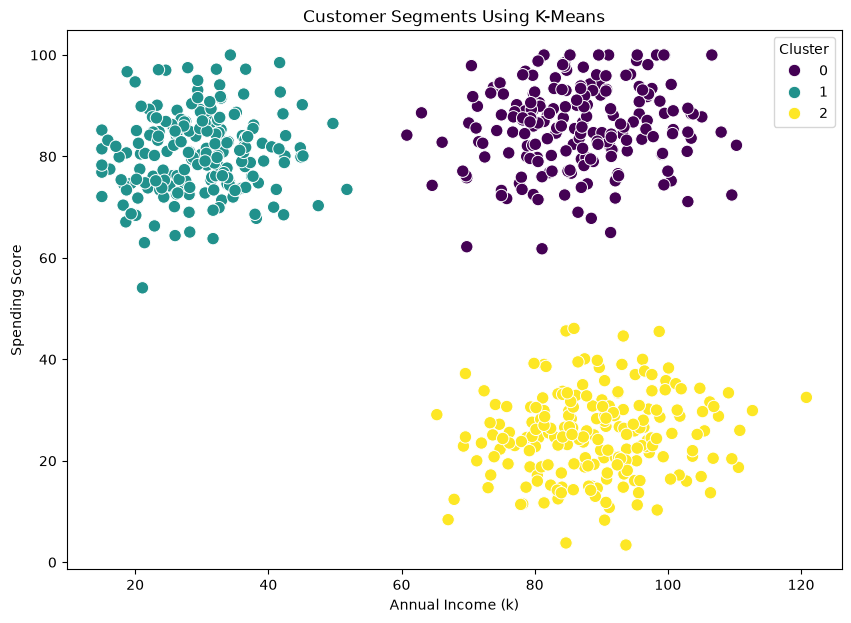

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    hue="cluster",
    palette="viridis",
    s=80
)

plt.title("Customer Segments Using K-Means")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")

plt.show()

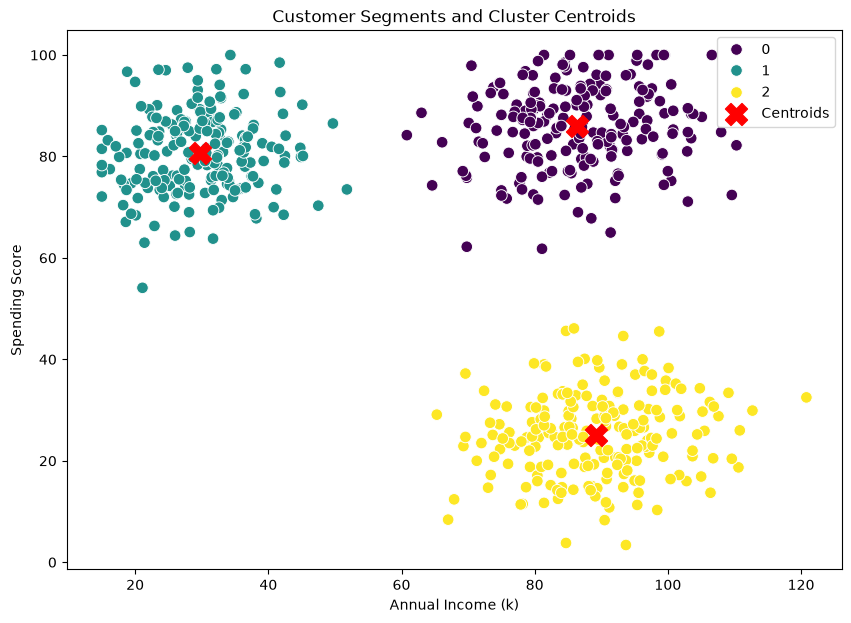

In [33]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    hue="cluster",
    palette="viridis",
    s=70
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.title("Customer Segments and Cluster Centroids")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

In [34]:
final_cluster_summary

,customer_count,average_income,average_spending
cluster,,,
0,200,86.28,85.96
1,200,29.71,80.63
2,200,89.14,25.07


In [35]:
persona_mapping = {
    0: "Budget Customers",
    1: "Potential Customers",
    2: "High-Value Customers"
}

In [36]:
df["persona"] = df["cluster"].map(persona_mapping)

In [37]:
df.head()

,annual_income_k,spending_score,cluster,persona
0,34.0,82.9,1,Potential Customers
1,28.9,84.5,1,Potential Customers
2,35.2,88.7,1,Potential Customers
3,42.2,88.4,1,Potential Customers
4,28.1,69.0,1,Potential Customers


In [38]:
df["persona"].value_counts()

persona
Potential Customers     200
High-Value Customers    200
Budget Customers        200
Name: count, dtype: int64

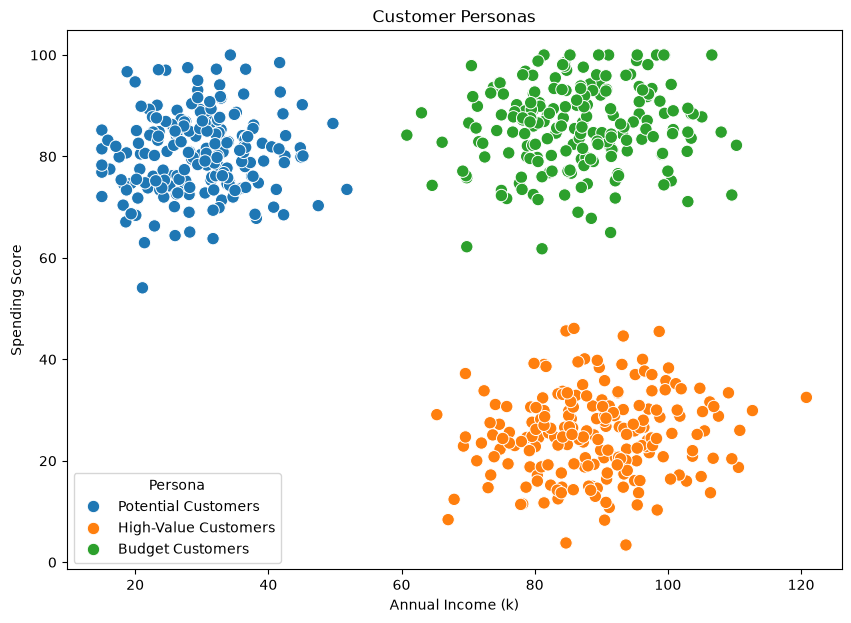

In [39]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    hue="persona",
    s=80
)

plt.title("Customer Personas")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")

plt.legend(title="Persona")

plt.show()

In [40]:
df.to_csv(
    "../data/segmented_customers.csv",
    index=False
)

In [41]:
df.head(10)

,annual_income_k,spending_score,cluster,persona
0,34.0,82.9,1,Potential Customers
1,28.9,84.5,1,Potential Customers
2,35.2,88.7,1,Potential Customers
3,42.2,88.4,1,Potential Customers
4,28.1,69.0,1,Potential Customers
5,28.1,72.5,1,Potential Customers
6,42.6,84.1,1,Potential Customers
7,36.1,84.1,1,Potential Customers
8,26.2,84.1,1,Potential Customers
9,34.3,100.0,1,Potential Customers


In [42]:
df.shape

(600, 4)

In [43]:
persona_mapping = {
    0: "High-Value Customers",
    1: "High-Spending Budget Customers",
    2: "Low-Spending High-Income Customers"
}

In [44]:
df["persona"] = df["cluster"].map(persona_mapping)

df.head()

,annual_income_k,spending_score,cluster,persona
0,34.0,82.9,1,High-Spending Budget Customers
1,28.9,84.5,1,High-Spending Budget Customers
2,35.2,88.7,1,High-Spending Budget Customers
3,42.2,88.4,1,High-Spending Budget Customers
4,28.1,69.0,1,High-Spending Budget Customers


In [45]:
df[["cluster", "persona"]].drop_duplicates().sort_values("cluster")

,cluster,persona
400,0,High-Value Customers
0,1,High-Spending Budget Customers
200,2,Low-Spending High-Income Customers


In [46]:
df["persona"].value_counts()

persona
High-Spending Budget Customers        200
Low-Spending High-Income Customers    200
High-Value Customers                  200
Name: count, dtype: int64

In [47]:
persona_summary = df.groupby("persona").agg(
    customer_count=("persona", "count"),
    average_income=("annual_income_k", "mean"),
    average_spending=("spending_score", "mean")
)

persona_summary = persona_summary.round(2)

persona_summary

,customer_count,average_income,average_spending
persona,,,
High-Spending Budget Customers,200,29.71,80.63
High-Value Customers,200,86.28,85.96
Low-Spending High-Income Customers,200,89.14,25.07


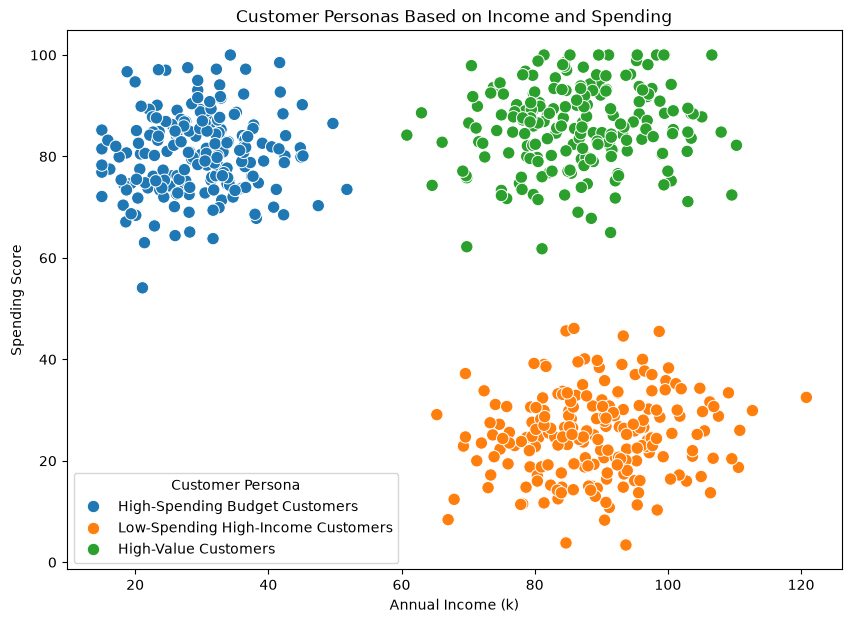

In [48]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    hue="persona",
    s=80
)

plt.title("Customer Personas Based on Income and Spending")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.legend(title="Customer Persona")

plt.show()

In [49]:
centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=[
        "annual_income_k",
        "spending_score"
    ]
)

centroids_df

,annual_income_k,spending_score
0,86.2840,85.9550
1,29.7140,80.6345
2,89.1445,25.0720


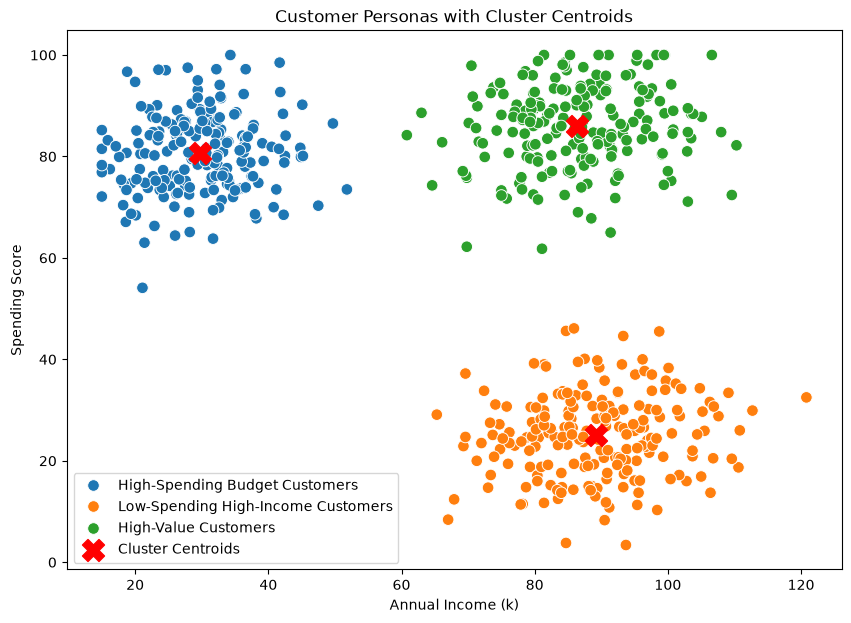

In [50]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="annual_income_k",
    y="spending_score",
    hue="persona",
    s=70
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    marker="X",
    s=250,
    color="red",
    label="Cluster Centroids"
)

plt.title("Customer Personas with Cluster Centroids")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

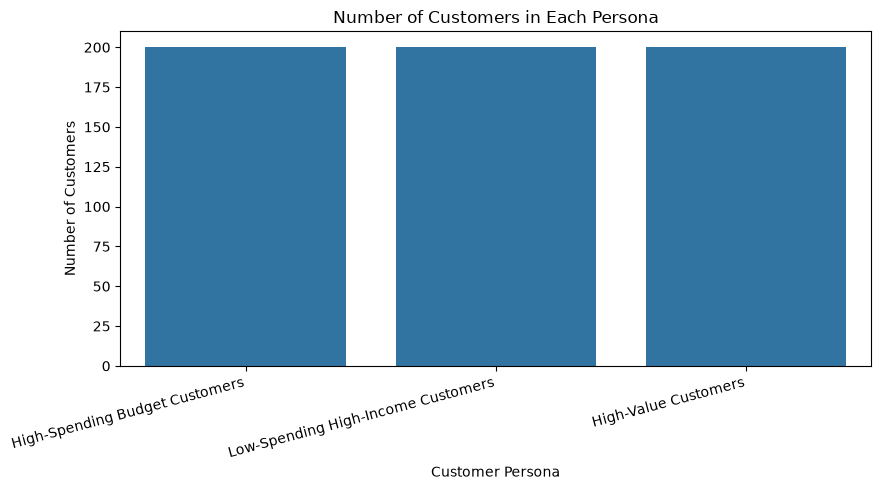

In [51]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="persona"
)

plt.title("Number of Customers in Each Persona")
plt.xlabel("Customer Persona")
plt.ylabel("Number of Customers")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()
plt.show()

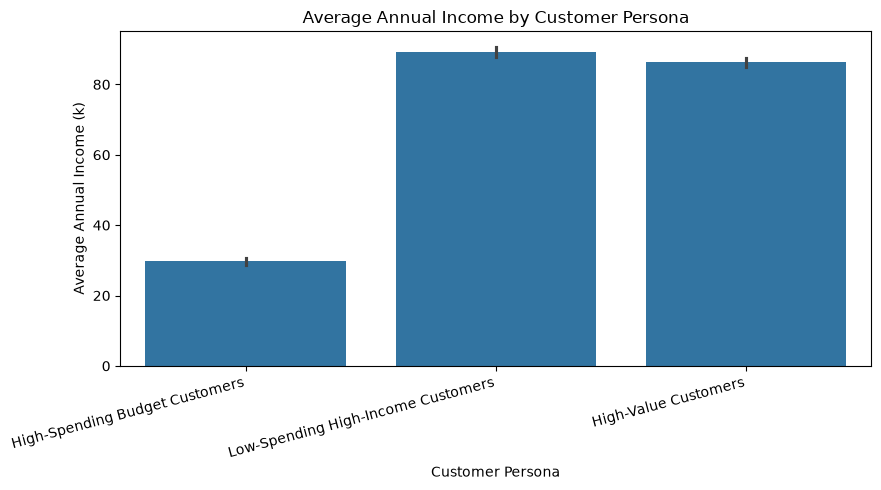

In [52]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="persona",
    y="annual_income_k"
)

plt.title("Average Annual Income by Customer Persona")
plt.xlabel("Customer Persona")
plt.ylabel("Average Annual Income (k)")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()
plt.show()

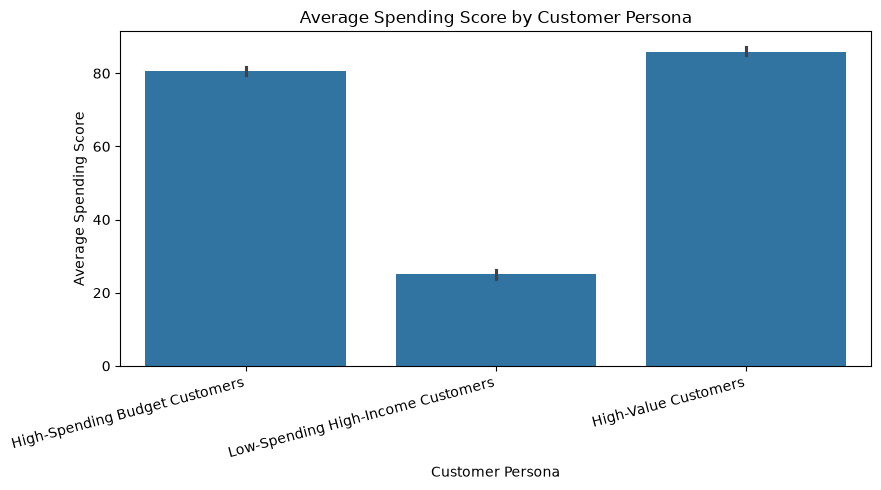

In [53]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="persona",
    y="spending_score"
)

plt.title("Average Spending Score by Customer Persona")
plt.xlabel("Customer Persona")
plt.ylabel("Average Spending Score")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()
plt.show()

In [54]:
df.to_csv(
    "../data/segmented_customers.csv",
    index=False
)

In [55]:
segmented_df = pd.read_csv(
    "../data/segmented_customers.csv"
)

segmented_df.head()

,annual_income_k,spending_score,cluster,persona
0,34.0,82.9,1,High-Spending Budget Customers
1,28.9,84.5,1,High-Spending Budget Customers
2,35.2,88.7,1,High-Spending Budget Customers
3,42.2,88.4,1,High-Spending Budget Customers
4,28.1,69.0,1,High-Spending Budget Customers


In [56]:
segmented_df.shape

(600, 4)

In [57]:
segmented_df.columns

Index(['annual_income_k', 'spending_score', 'cluster', 'persona'], dtype='str')

In [58]:
import joblib

In [59]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']

In [60]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [61]:
joblib.dump(
    persona_mapping,
    "../models/persona_mapping.pkl"
)

['../models/persona_mapping.pkl']

In [62]:
import os

os.listdir("../models")

['kmeans_model.pkl', 'persona_mapping.pkl', 'scaler.pkl']

In [63]:
loaded_kmeans = joblib.load(
    "../models/kmeans_model.pkl"
)

loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

loaded_persona_mapping = joblib.load(
    "../models/persona_mapping.pkl"
)

In [64]:
print(loaded_kmeans)

KMeans(n_clusters=3, n_init=10, random_state=42)


In [65]:
print(loaded_scaler)

StandardScaler()


In [66]:
print(loaded_persona_mapping)

{0: 'High-Value Customers', 1: 'High-Spending Budget Customers', 2: 'Low-Spending High-Income Customers'}


In [67]:
new_customer = pd.DataFrame({
    "annual_income_k": [80],
    "spending_score": [90]
})

new_customer

,annual_income_k,spending_score
0,80,90


In [68]:
new_customer_scaled = loaded_scaler.transform(
    new_customer
)

In [69]:
predicted_cluster = loaded_kmeans.predict(
    new_customer_scaled
)

predicted_cluster

array([0], dtype=int32)

In [70]:
cluster_id = int(predicted_cluster[0])

persona = loaded_persona_mapping[cluster_id]

print("Cluster:", cluster_id)
print("Persona:", persona)

Cluster: 0
Persona: High-Value Customers


In [71]:
test_customers = pd.DataFrame({
    "annual_income_k": [25, 90, 85],
    "spending_score": [80, 20, 90]
})

test_customers

,annual_income_k,spending_score
0,25,80
1,90,20
2,85,90


In [72]:
test_scaled = loaded_scaler.transform(
    test_customers
)

In [73]:
test_clusters = loaded_kmeans.predict(
    test_scaled
)

test_clusters

array([1, 2, 0], dtype=int32)

In [74]:
test_customers["cluster"] = test_clusters

test_customers["persona"] = test_customers["cluster"].map(
    loaded_persona_mapping
)

test_customers

,annual_income_k,spending_score,cluster,persona
0,25,80,1,High-Spending Budget Customers
1,90,20,2,Low-Spending High-Income Customers
2,85,90,0,High-Value Customers


In [75]:
def predict_persona(
    annual_income_k,
    spending_score
):
    
    new_customer = pd.DataFrame({
        "annual_income_k": [annual_income_k],
        "spending_score": [spending_score]
    })

    scaled_customer = loaded_scaler.transform(
        new_customer
    )

    cluster = loaded_kmeans.predict(
        scaled_customer
    )[0]

    persona = loaded_persona_mapping[int(cluster)]

    return int(cluster), persona

In [76]:
cluster, persona = predict_persona(
    30,
    75
)

print("Cluster:", cluster)
print("Persona:", persona)

Cluster: 1
Persona: High-Spending Budget Customers


In [77]:
cluster, persona = predict_persona(
    95,
    20
)

print("Cluster:", cluster)
print("Persona:", persona)

Cluster: 2
Persona: Low-Spending High-Income Customers


In [78]:
cluster, persona = predict_persona(
    120,
    100
)

print("Cluster:", cluster)
print("Persona:", persona)

Cluster: 0
Persona: High-Value Customers


In [79]:
cluster, persona = predict_persona(
    15,
    5
)

print("Cluster:", cluster)
print("Persona:", persona)

Cluster: 2
Persona: Low-Spending High-Income Customers


In [80]:
cluster, persona = predict_persona(80, 90)

print(cluster)
print(persona)

0
High-Value Customers


In [82]:
# Model Evaluation Summary

evaluation_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

evaluation_results = evaluation_results.round(4)

evaluation_results
# Best K based on Silhouette Score

best_k = evaluation_results.loc[
    evaluation_results["Silhouette Score"].idxmax(),
    "K"
]

best_silhouette_score = evaluation_results["Silhouette Score"].max()

print("Best K based on Silhouette Score:", int(best_k))
print("Best Silhouette Score:", round(best_silhouette_score, 4))

Best K based on Silhouette Score: 3
Best Silhouette Score: 0.7357


In [83]:
selected_silhouette_score = evaluation_results.loc[
    evaluation_results["K"] == optimal_k,
    "Silhouette Score"
].iloc[0]

print("Selected K:", optimal_k)
print(
    "Silhouette Score for selected K:",
    round(selected_silhouette_score, 4)
)

Selected K: 3
Silhouette Score for selected K: 0.7357


In [84]:
model_evaluation = pd.DataFrame({
    "Metric": [
        "Algorithm",
        "Number of Clusters",
        "Number of Customers",
        "Number of Features",
        "Silhouette Score"
    ],
    "Value": [
        "K-Means",
        optimal_k,
        len(df),
        2,
        round(selected_silhouette_score, 4)
    ]
})

model_evaluation

,Metric,Value
0,Algorithm,K-Means
1,Number of Clusters,3
2,Number of Customers,600
3,Number of Features,2
4,Silhouette Score,0.7357


In [85]:
evaluation_results

,K,Inertia,Silhouette Score
0,2,493.6612,0.5805
1,3,104.7807,0.7357
2,4,89.2040,0.6025
3,5,74.6277,0.4722
4,6,64.9066,0.3374
5,7,58.0079,0.3421
6,8,51.2391,0.3399
7,9,44.8049,0.3569
8,10,40.1832,0.3548


In [86]:
print("Best K based on Silhouette Score:", int(best_k))
print("Best Silhouette Score:", round(best_silhouette_score, 4))

Best K based on Silhouette Score: 3
Best Silhouette Score: 0.7357


In [90]:
# ============================================================
# SAVE MODEL EVALUATION RESULTS
# ============================================================

evaluation_data = {
    "k_values": list(K_range),
    "inertia": inertia,
    "silhouette_scores": silhouette_scores,
    "optimal_k": optimal_k,
    "selected_silhouette_score": selected_silhouette_score
}

with open("../models/model_evaluation.pkl", "wb") as file:
    pickle.dump(evaluation_data, file)

print("Model evaluation results saved successfully.")

Model evaluation results saved successfully.
